In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import pickle

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("loanapproval.csv")
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [4]:
df.head()

df.tail()

df.sample(5)

df.shape

df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [5]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["loan_approved"].value_counts()

loan_approved
1    729
0    271
Name: count, dtype: int64

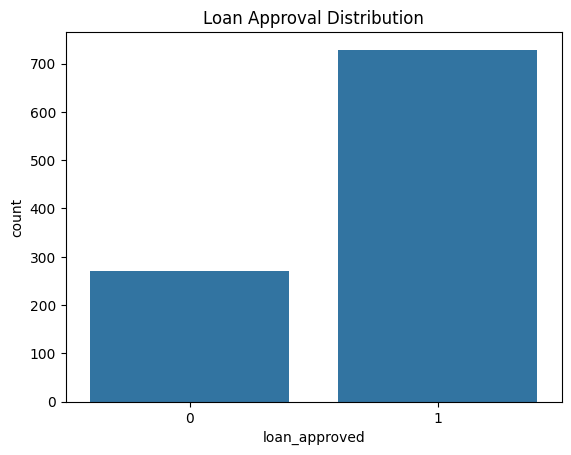

In [8]:
sns.countplot(x="loan_approved", data=df)

plt.title("Loan Approval Distribution")

plt.show()

#EDA

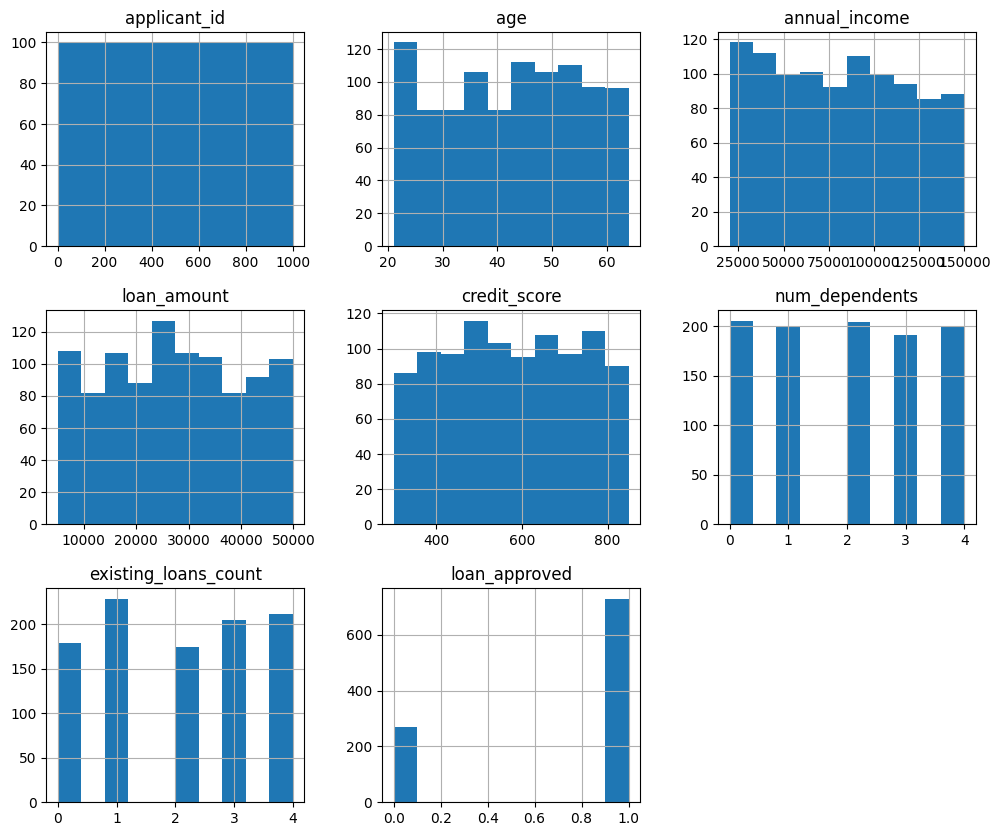

In [9]:
df.hist(figsize=(12,10))

plt.show()

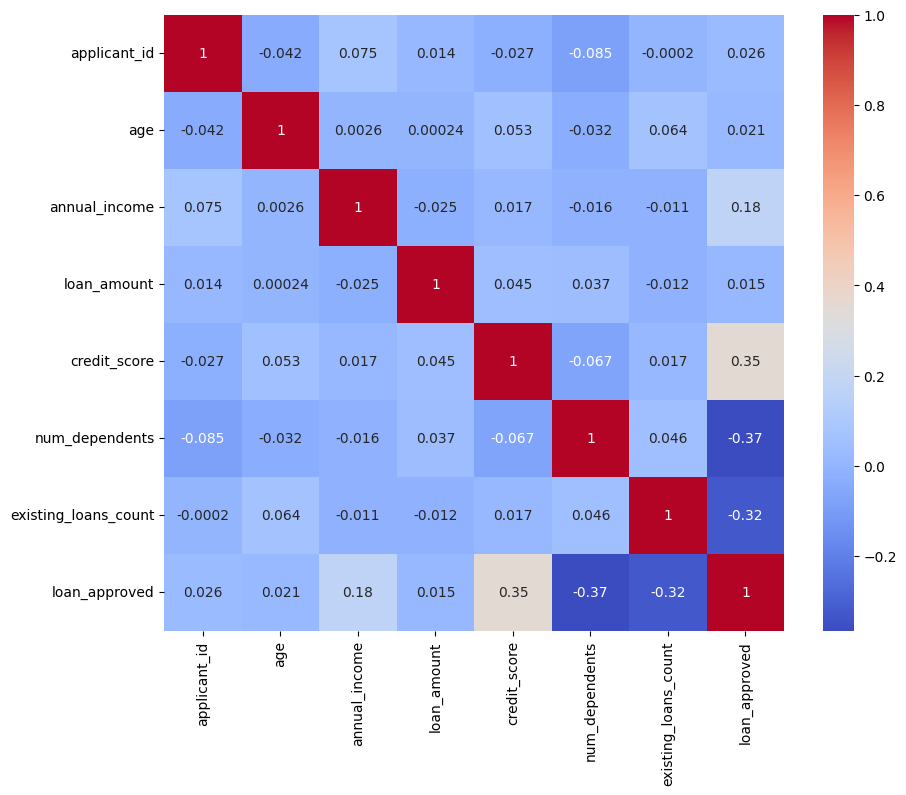

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

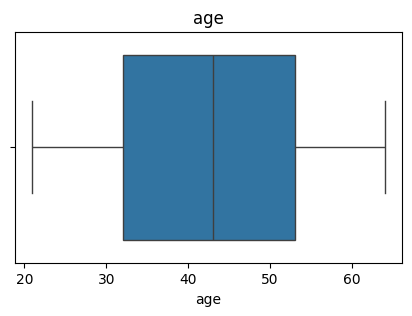

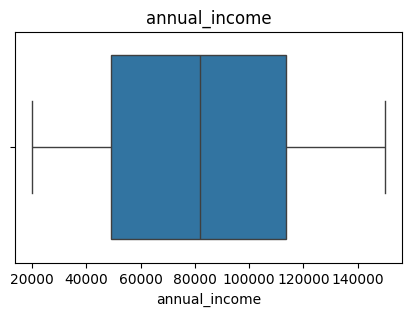

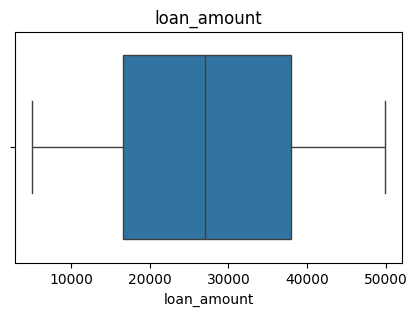

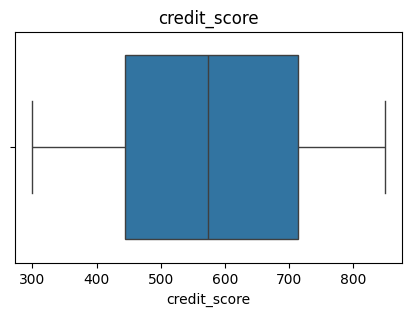

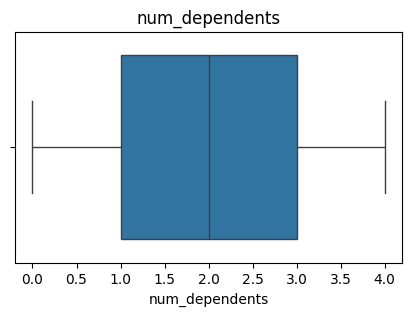

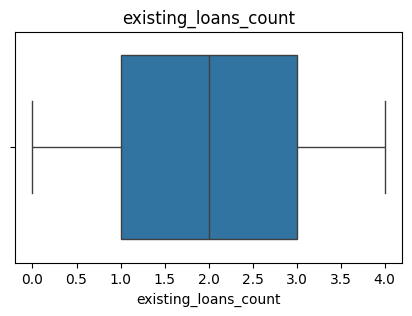

In [11]:
numerical_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "num_dependents",
    "existing_loans_count"
]

for col in numerical_columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

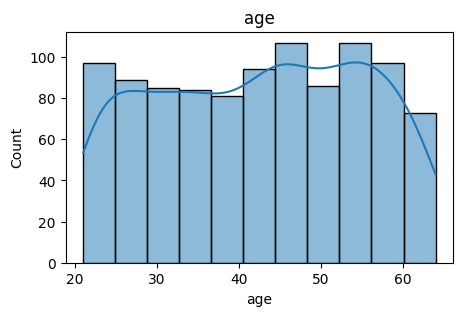

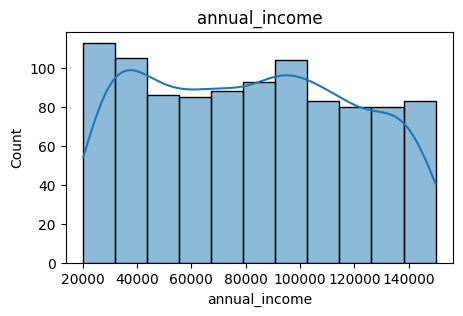

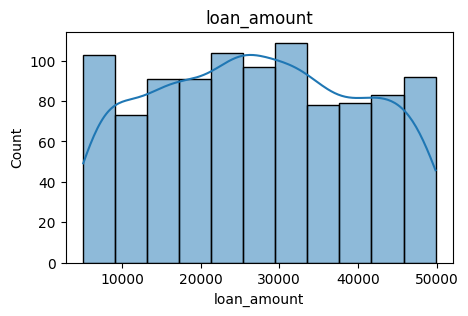

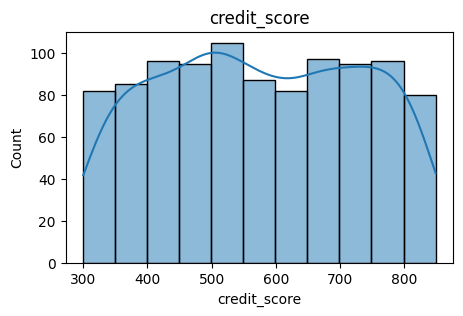

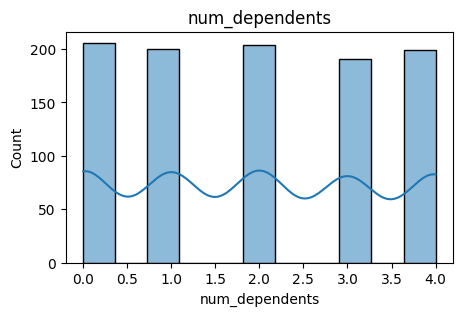

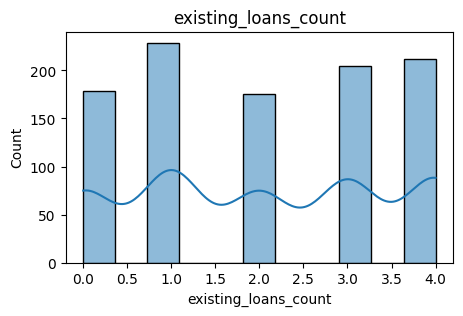

In [12]:
for col in numerical_columns:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

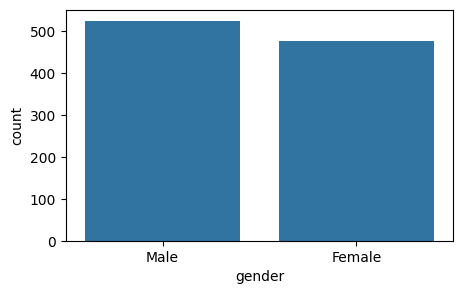

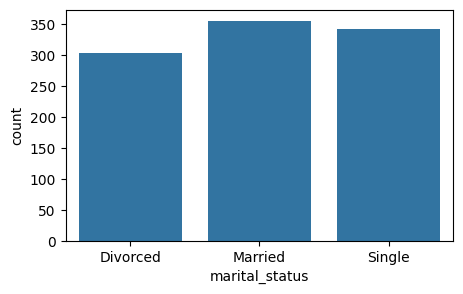

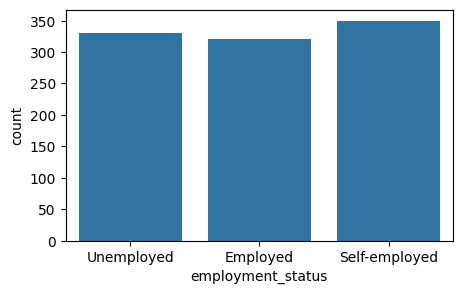

In [13]:
categorical_columns = [
    "gender",
    "marital_status",
    "employment_status"
]

for col in categorical_columns:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df)
    plt.show()

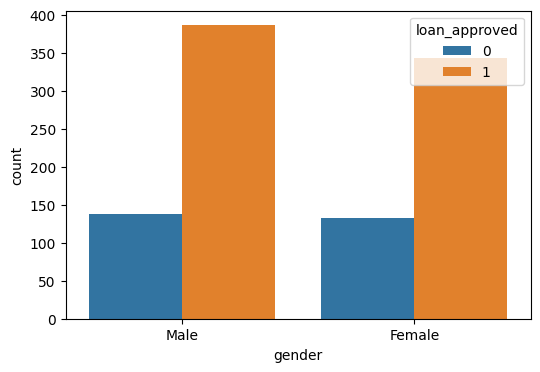

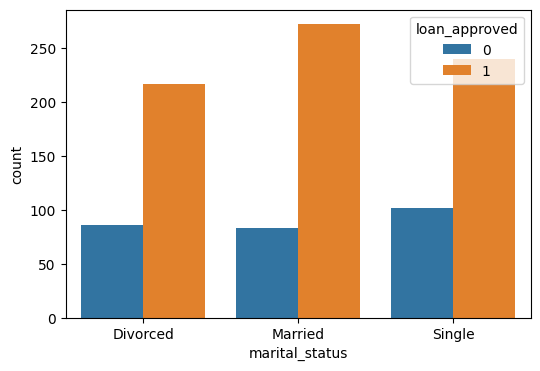

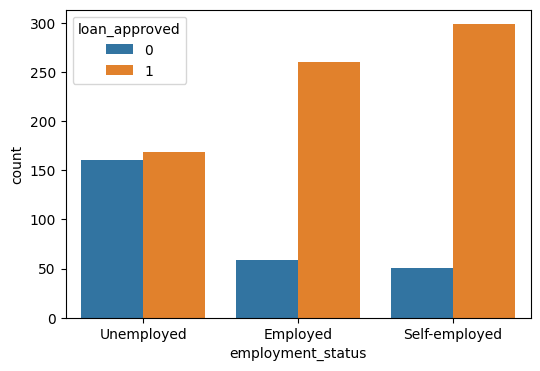

In [14]:
# RELATIONSHIP WITH TARGET

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(
        x=col,
        hue="loan_approved",
        data=df
    )
    plt.show()

In [15]:
df_processed = df.copy()

In [16]:
df_processed.drop("applicant_id", axis=1, inplace=True)

In [17]:
df_processed.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [18]:
df_processed.isnull().sum()

age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [19]:
df_processed.duplicated().sum()

np.int64(0)

In [20]:
cat_cols = df_processed.select_dtypes(include="object").columns

cat_cols

Index(['gender', 'marital_status', 'employment_status'], dtype='object')

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    df_processed[col] = encoder.fit_transform(df_processed[col])

In [22]:
df_processed.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,1,0,100073,7169,793,1,1,2,1
1,49,1,1,112197,23556,789,0,2,0,1
2,35,1,0,84429,27052,372,1,4,2,0
3,63,0,2,124195,11313,808,3,4,1,1
4,28,0,1,81627,13315,689,0,1,2,1


In [23]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   1000 non-null   int64
 1   gender                1000 non-null   int64
 2   marital_status        1000 non-null   int64
 3   annual_income         1000 non-null   int64
 4   loan_amount           1000 non-null   int64
 5   credit_score          1000 non-null   int64
 6   num_dependents        1000 non-null   int64
 7   existing_loans_count  1000 non-null   int64
 8   employment_status     1000 non-null   int64
 9   loan_approved         1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB


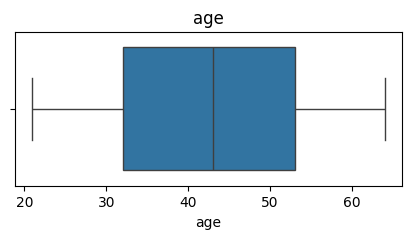

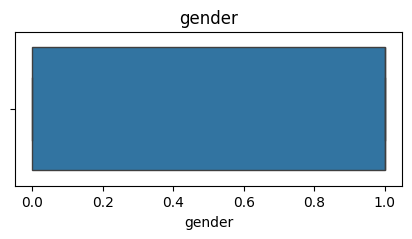

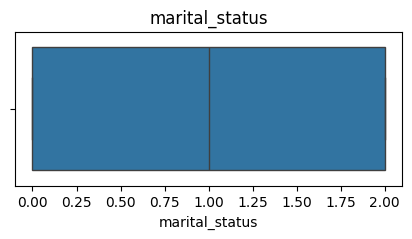

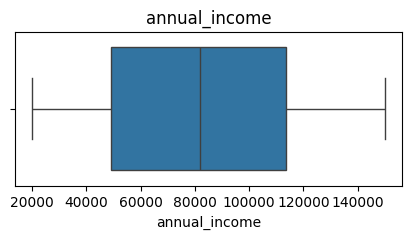

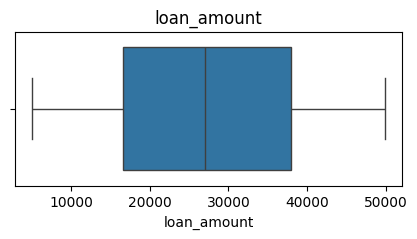

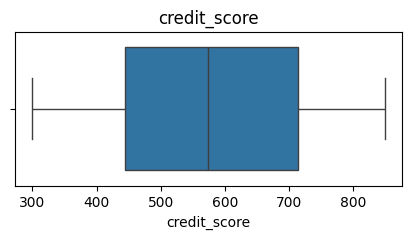

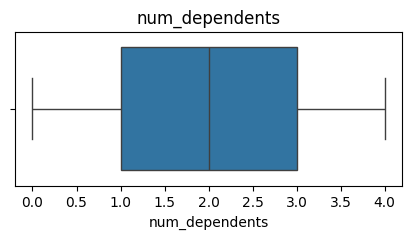

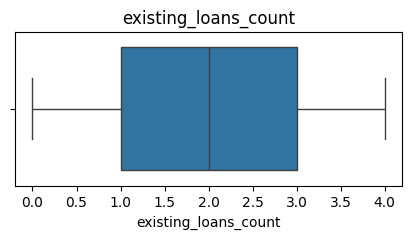

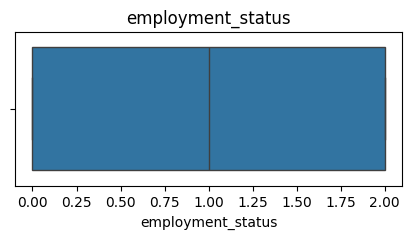

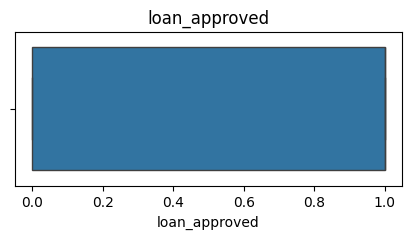

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_processed.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df_processed[col])
    plt.title(col)
    plt.show()

In [25]:
df_processed["loan_approved"].value_counts()

loan_approved
1    729
0    271
Name: count, dtype: int64

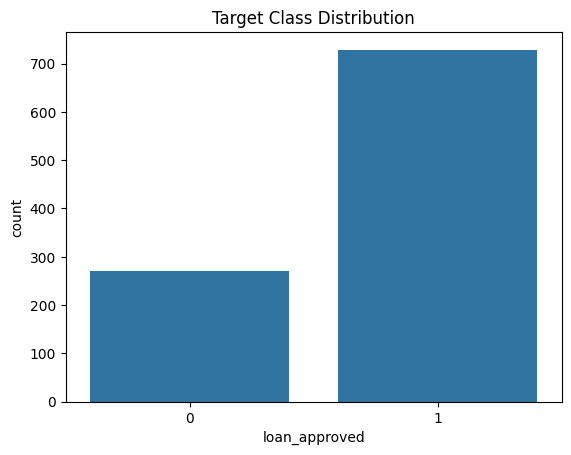

In [26]:
sns.countplot(x="loan_approved", data=df_processed)
plt.title("Target Class Distribution")
plt.show()

In [27]:
df_processed.to_csv(
    "loanapproval_processed.csv",
    index=False
)

In [28]:
X = df_processed.drop("loan_approved", axis=1)

y = df_processed["loan_approved"]

In [29]:
X.columns

Index(['age', 'gender', 'marital_status', 'annual_income', 'loan_amount',
       'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status'],
      dtype='object')

In [30]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1000, 9)
Target Shape : (1000,)


In [31]:
X.dtypes

age                     int64
gender                  int64
marital_status          int64
annual_income           int64
loan_amount             int64
credit_score            int64
num_dependents          int64
existing_loans_count    int64
employment_status       int64
dtype: object

In [32]:
y.value_counts()

loan_approved
1    729
0    271
Name: count, dtype: int64

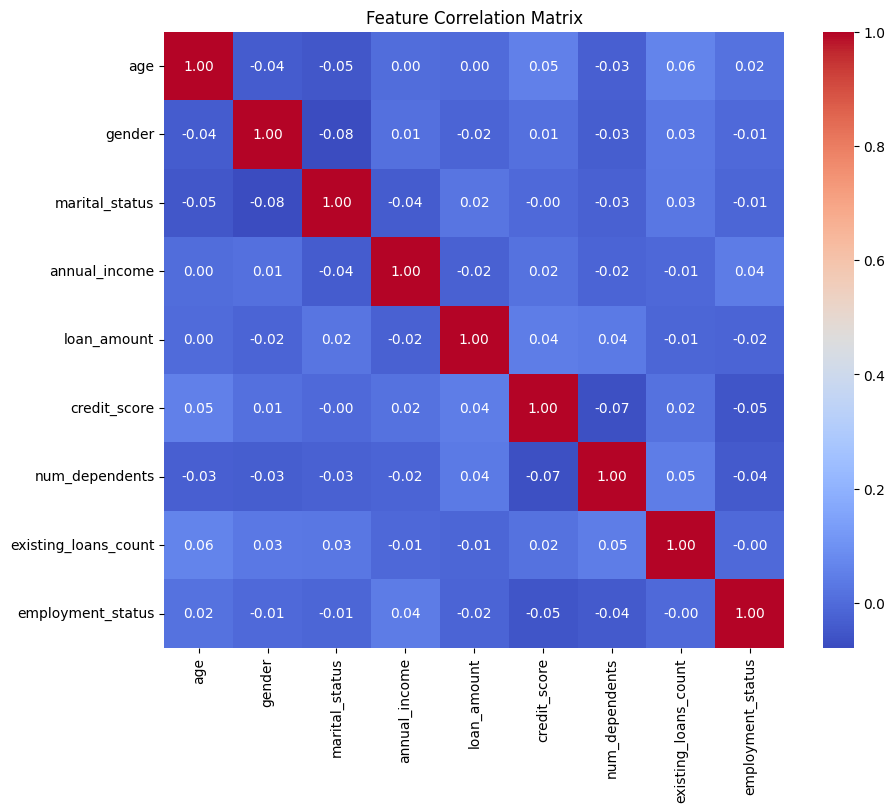

In [33]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [34]:
X.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status
0,59,1,0,100073,7169,793,1,1,2
1,49,1,1,112197,23556,789,0,2,0
2,35,1,0,84429,27052,372,1,4,2
3,63,0,2,124195,11313,808,3,4,1
4,28,0,1,81627,13315,689,0,1,2


In [35]:
y.head()

0    1
1    1
2    0
3    1
4    1
Name: loan_approved, dtype: int64

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (800, 9)
Testing Features  : (200, 9)
Training Target   : (800,)
Testing Target    : (200,)


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

In [40]:
X_train_scaled = scaler.fit_transform(X_train)

In [41]:
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [43]:
X_train_scaled.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status
0,1.143619,-1.056599,-0.037308,0.262126,1.305990,-0.184438,0.696989,1.393526,-1.255264
1,-1.534276,0.946433,-0.037308,-1.196668,0.219405,-0.190843,-0.008823,-0.757254,1.230407
2,0.986096,0.946433,-0.037308,1.607454,-0.534459,0.033349,-0.008823,1.393526,-0.012428
3,0.040956,-1.056599,-0.037308,-0.056443,0.087884,-0.575173,-0.714635,-1.474181,-1.255264
4,0.513526,0.946433,1.206296,-0.470901,0.455789,-0.511118,-0.714635,1.393526,-0.012428


In [44]:
import os

os.getcwd()

'C:\\Users\\Vivek Pandey\\OneDrive\\Desktop\\Loan Approval prediction'

In [45]:
os.listdir()

['.gitignore',
 '.ipynb_checkpoints',
 'app.py',
 'feature_importance.csv',
 'loanapproval.csv',
 'loanapproval_processed.csv',
 'loan_approval_prediction.ipynb',
 'models',
 'requirements.txt']

In [46]:
import os

os.makedirs("models", exist_ok=True)

In [47]:
import pickle

with open("models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [48]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Vivek Pandey\OneDrive\Desktop\Loan Approval prediction
['.gitignore', '.ipynb_checkpoints', 'app.py', 'feature_importance.csv', 'loanapproval.csv', 'loanapproval_processed.csv', 'loan_approval_prediction.ipynb', 'models', 'requirements.txt']


In [49]:
import os

os.listdir("models")

['best_model.pkl', 'scaler.pkl']